In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd

In [4]:
df = pd.read_csv("Diabetes_Classification_Dataset.csv")
df.head()

,Age,Gender,BMI,WaistCircumference,BloodPressure,FastingGlucose,HbA1c,Insulin,PhysicalActivity,FamilyHistory,Smoking,Diet,Pregnancies,DiabetesStatus
0,40,Male,40.7,95.0,102,87,5.3,37.0,Moderate,Yes,Yes,Healthy,0,Prediabetes
1,47,Female,28.0,85.0,162,98,8.5,6.0,Low,Yes,Yes,Healthy,3,Prediabetes
2,22,Male,31.4,78.0,105,149,7.6,37.0,High,No,Yes,Poor,0,Diabetes
3,56,Female,33.3,NaN,162,99,8.5,7.0,Low,Yes,No,Mixed,7,Diabetes
4,57,Female,40.2,93.0,121,151,6.5,NaN,Low,No,No,Poor,7,Diabetes


In [5]:
print(df.shape)
print(df.dtypes)
print(df.describe())


(120, 14)
Age                     int64
Gender                    str
BMI                   float64
WaistCircumference    float64
BloodPressure           int64
FastingGlucose          int64
HbA1c                 float64
Insulin               float64
PhysicalActivity          str
FamilyHistory             str
Smoking                   str
Diet                      str
Pregnancies             int64
DiabetesStatus            str
dtype: object
              Age         BMI  WaistCircumference  BloodPressure  \
count  120.000000  118.000000          118.000000     120.000000   
mean    45.233333   30.883051           96.279661     131.500000   
std     18.287955    7.024418           18.337708      24.346242   
min     21.000000   18.000000           70.000000      90.000000   
25%     30.000000   24.925000           79.000000     109.750000   
50%     41.000000   32.450000           93.000000     132.500000   
75%     59.250000   36.700000          111.000000     154.250000   
max     79.0

In [6]:
print(df.isnull().sum())

Age                   0
Gender                0
BMI                   2
WaistCircumference    2
BloodPressure         0
FastingGlucose        0
HbA1c                 2
Insulin               2
PhysicalActivity      0
FamilyHistory         0
Smoking               0
Diet                  2
Pregnancies           0
DiabetesStatus        0
dtype: int64


In [7]:
print(df.duplicated().sum())
df=df.drop_duplicates()
print(df.shape)

3
(117, 14)


In [8]:
df['BMI']=df['BMI'].fillna(df['BMI'].mean())
df['WaistCircumference']=df['WaistCircumference'].fillna(df['WaistCircumference'].mean())
df['HbA1c']=df['HbA1c'].fillna(df['HbA1c'].mean())
df['Insulin']=df['Insulin'].fillna(df['Insulin'].mean())
df["Diet"] = df["Diet"].fillna(df["Diet"].mode()[0])

print(df.head())

   Age  Gender   BMI  WaistCircumference  BloodPressure  FastingGlucose  \
0   40    Male  40.7           95.000000            102              87   
1   47  Female  28.0           85.000000            162              98   
2   22    Male  31.4           78.000000            105             149   
3   56  Female  33.3           95.834783            162              99   
4   57  Female  40.2           93.000000            121             151   

   HbA1c    Insulin PhysicalActivity FamilyHistory Smoking     Diet  \
0    5.3  37.000000         Moderate           Yes     Yes  Healthy   
1    8.5   6.000000              Low           Yes     Yes  Healthy   
2    7.6  37.000000             High            No     Yes     Poor   
3    8.5   7.000000              Low           Yes      No    Mixed   
4    6.5  22.278261              Low            No      No     Poor   

   Pregnancies DiabetesStatus  
0            0    Prediabetes  
1            3    Prediabetes  
2            0       Diabe

here, diet is the only cat var, so ive used mode to fill and for num values ive used mean.

In [9]:
le=LabelEncoder()
for c in ['Gender','PhysicalActivity','FamilyHistory','Smoking','Diet','DiabetesStatus']:
    df[c]=le.fit_transform(df[c])
df.head()

,Age,Gender,BMI,WaistCircumference,BloodPressure,FastingGlucose,HbA1c,Insulin,PhysicalActivity,FamilyHistory,Smoking,Diet,Pregnancies,DiabetesStatus
0,40,1,40.7,95.000000,102,87,5.3,37.000000,2,1,1,0,0,2
1,47,0,28.0,85.000000,162,98,8.5,6.000000,1,1,1,0,3,2
2,22,1,31.4,78.000000,105,149,7.6,37.000000,0,0,1,2,0,0
3,56,0,33.3,95.834783,162,99,8.5,7.000000,1,1,0,1,7,0
4,57,0,40.2,93.000000,121,151,6.5,22.278261,1,0,0,2,7,0


In [10]:
scaler=MinMaxScaler()
cols=['Age','BMI','WaistCircumference','BloodPressure','FastingGlucose','HbA1c', 'Insulin','Pregnancies']
df[cols]=scaler.fit_transform(df[cols])
df.head()

,Age,Gender,BMI,WaistCircumference,BloodPressure,FastingGlucose,HbA1c,Insulin,PhysicalActivity,FamilyHistory,Smoking,Diet,Pregnancies,DiabetesStatus
0,0.327586,1,0.945833,0.416667,0.1500,0.072727,0.061538,0.918919,2,1,1,0,0.000,2
1,0.448276,0,0.416667,0.250000,0.9000,0.139394,0.553846,0.081081,1,1,1,0,0.375,2
2,0.017241,1,0.558333,0.133333,0.1875,0.448485,0.415385,0.918919,0,0,1,2,0.000,0
3,0.603448,0,0.637500,0.430580,0.9000,0.145455,0.553846,0.108108,1,1,0,1,0.875,0
4,0.620690,0,0.925000,0.383333,0.3875,0.460606,0.246154,0.521034,1,0,0,2,0.875,0


In [11]:
X=df[['Age','Gender','BMI','BloodPressure','FastingGlucose','HbA1c','Insulin','FamilyHistory','Smoking','Diet','Pregnancies','PhysicalActivity','WaistCircumference']]
y=df['DiabetesStatus']

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(93, 13)
(24, 13)


In [13]:
model = Sequential()

model.add(Dense(20, activation='relu', input_shape=(13,)))
model.add(Dropout(0.2))

model.add(Dense(10, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(5, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(3, activation='softmax'))

c:\Users\yalin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 563 (2.20 KB)

 Trainable params: 563 (2.20 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [27]:
history=model.fit(X_train,y_train,epochs=50,batch_size=7,validation_split=0.2)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8108 - loss: 0.4304 - val_accuracy: 0.5263 - val_loss: 1.4250
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8108 - loss: 0.3894 - val_accuracy: 0.5263 - val_loss: 1.3874
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8649 - loss: 0.4415 - val_accuracy: 0.5263 - val_loss: 1.4297
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7568 - loss: 0.4381 - val_accuracy: 0.5263 - val_loss: 1.4796
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7162 - loss: 0.6521 - val_accuracy: 0.5263 - val_loss: 1.4212
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7838 - loss: 0.4508 - val_accuracy: 0.5263 - val_loss: 1.3880
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7973 - loss: 0.5169 - val_accuracy: 0.5263 - val_loss: 1.3410
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8108 - loss: 0.4422 - val_accuracy: 0.5263 - val_lo

In [28]:
loss,accuracy=model.evaluate(X_test,y_test)
print('Test Accuracy:',accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7500 - loss: 0.7575
Test Accuracy: 0.75


In [29]:
model.evaluate(X_test,y_test,verbose=0)

[0.7574706077575684, 0.75]

In [31]:
y_pred=model.predict(X_test)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
[[0.10744278 0.00392674 0.8886305 ]
 [0.04059492 0.04871299 0.9106921 ]
 [0.37155053 0.09994835 0.52850115]
 [0.3146167  0.32100624 0.36437708]
 [0.83156383 0.01347085 0.1549653 ]
 [0.0061178  0.00338859 0.9904937 ]
 [0.7975109  0.00812055 0.19436859]
 [0.8550937  0.00697602 0.13793021]
 [0.78738487 0.00637973 0.2062354 ]
 [0.89028    0.00218914 0.10753089]
 [0.3724364  0.12443431 0.50312936]
 [0.2732793  0.04443227 0.6822884 ]
 [0.6735471  0.09354047 0.23291244]
 [0.0472077  0.3778831  0.57490927]
 [0.02370348 0.0038996  0.97239685]
 [0.20945793 0.243485   0.54705703]
 [0.05630184 0.00891453 0.93478364]
 [0.00735525 0.08218878 0.91045594]
 [0.7845477  0.0381597  0.17729269]
 [0.05149087 0.41655967 0.5319495 ]
 [0.14068775 0.01929624 0.840016  ]
 [0.03494588 0.00160949 0.9634446 ]
 [0.04724566 0.01371347 0.9390409 ]
 [0.22014152 0.43115616 0.3487023 ]]


In [32]:
import numpy as np
predicted_class=np.argmax(y_pred,axis=1)
print(predicted_class)

[2 2 2 2 0 2 0 0 0 0 2 2 0 2 2 2 2 2 0 2 2 2 2 1]


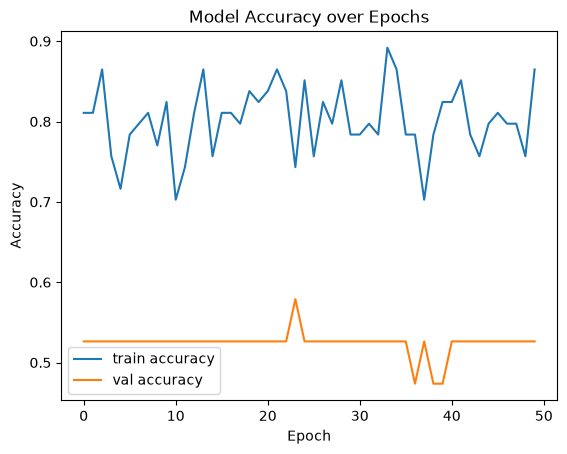

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.show()